# Article 1: Effect of heterogenous emissivity field on thermal results during additive manufacturing process

## Set-up workspace

### Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from brokenaxes import brokenaxes
from matplotlib.colors import LinearSegmentedColormap, Normalize
from pathlib import Path

# Set global error handling for NumPy
np.seterr(invalid='ignore', divide='ignore')
# import scienceplots
# plt.style.use(['science', 'grid'])

from TherMIFASOL.core.variables.GlobalVariables import (
    LINES_CRED, COLUMNS_CRED, FAC, T_SOLIDUS, T_LIQUIDUS, 
    T_SOLIDUS_GANDIN, T_LIQUIDUS_GANDIN, CET_IN718_fitting_parameters
)
from TherMIFASOL.core.variables.BoardCardFilterVariable import (
    params_clip, boundaries_data_selection, time_constant_parameters,
    params_first_order, boundaries_data_color, colors_plots_cordon
)
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer
)
from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array, dl_to_thermo
)
from TherMIFASOL.core.models.EmissivityEmpiricalLaws import (
    first_order_emissivity_article
)
from TherMIFASOL.core.models.ThermalGradientRegularized import (
    RegularizedThermalGradient
)
from TherMIFASOL.core.models.ThermalAnalysis import (
    hunt_data_on_isotherm, classify_growth_mode, display_hunt_criterion, display_G_and_R_on_images,
    display_G_and_R_on_images_old
)
from TherMIFASOL.core.utils.visualization import (
    setup_contour_parameters, plot_temperature_evolution, plot_thermal_images,
    create_csv_file, interpolate_color, interpolate_to_black, plot_differences
)
from TherMIFASOL.core.utils.ImageProcessing import (
    get_video_from_images
)


### Paths

In [2]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


# Path to data
#-------------------
data_path = os.path.join(
    PATH_DATA, "experiences/4 BoardCardFilter/DEC1/"
)


# Calibration tables
#-------------------

#   CRED:
array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp500__diaphMIN_bois2.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT100_deg1_diaphMIN_bois2_TRUSTWORTHY.npy"
        )
    )


# CET data for IN718 path
#------------------------
CET_path = os.path.join(BASE_DIR, "TherMIFASOL/resources/CET_INCONEL")


# Saving path
#------------
saving_path = os.path.join(BASE_DIR, "results/article/test")

### Functions

In [3]:
def create_position_mesh(params_clip, int_id_cordon, FAC, spot_diameter=int(0.8/FAC)):

    # Extract parameters
    delay = params_clip[int_id_cordon]['delay']
    upper_limit = params_clip[int_id_cordon]['upper limit px']

    # Determine direction
    direction = int_id_cordon % 2 == 0

    # Create y-coordinate matrix
    y_matrix_pos = (np.arange(0, 512) - upper_limit) * FAC

    # Create x-coordinate matrix based on direction
    if direction:
        x_matrix_pos = np.arange(639, -1, -1) * FAC
        x = 640 - int(delay * 16.7 / FAC)
        x_matrix_pos -= delay * 16.7
    else:
        x_matrix_pos = np.arange(0, 640) * FAC
        x = int(delay * 16.7 / FAC)
        x_matrix_pos -= delay * 16.7

    # Calculate reference point
    ref_point = (x, int(upper_limit + spot_diameter/2))

    # Create meshgrid
    chi, zeta = np.meshgrid(
        np.abs(x_matrix_pos),
        y_matrix_pos
    )

    # Create mask
    mask_prof = np.zeros_like(zeta, dtype=bool)
    mask_prof[:upper_limit, :] = True  # True == unwanted values

    return ref_point, chi, zeta, direction, mask_prof

## Three thermal images

In [4]:
list_method = ['Uniform (0.73)', 'First order']

information_targeted = {
        'thermal image':None,
        'Fourier thermal image':None,
        'shape quantification':None,
        'coordinates isotherm':None,
        'thermal gradient on isotherm':None,
        'solidification rate on isotherm':None,
        'hunt criteria coordinates':None,
        'classify growth mode':None
    }

DICT_STUDY_DATA = {key: information_targeted.copy() for key in list_method}

### Initialization stuff

#### Select reference image

In [5]:
int_id_cordon = 12
int_img_selected = params_clip[int_id_cordon]['snapshot']

array_raw_image = load_cred_array(
    path_image=os.path.join(data_path, f"CRED/data/layer_{int_id_cordon}/im_{int_img_selected}.npy")
)

#### Pyrometer wake
- The pyrometer is focused on a single, specific point on the wall. However, the melt pool moves along this wall during the deposition process. To simulate the pyrometer's effective recording when the melt pool passes through its observation point, we adjust the observation point in the image.

- Instead of capturing the melt pool as it naturally passes through the observation point, we shift the observation point in the image by the relative displacement speed. This adjustment mimics the pyrometer's recording as if the melt pool were actually moving through its fixed observation area.

- The relative path of the pyrometer created by this adjustment is called the "pyrometer wake."

- The concept of pyrometer wake relies on the assumption that the thermal field maintains a steady-state shape throughout the deposition of a single bead.

In [6]:
hauteur = int(0.8/FAC)  # Pyrometer spot size is 0.8 mm 
lim_sup_mm = 8.1
lim_sup = int((19.2-lim_sup_mm)/19.2*512 )

pyrometer_wake = np.zeros((LINES_CRED, COLUMNS_CRED, 4))
pyrometer_wake[lim_sup:lim_sup+hauteur,:,:]=1
pyrometer_wake[lim_sup:lim_sup+hauteur,:,3]=0.5

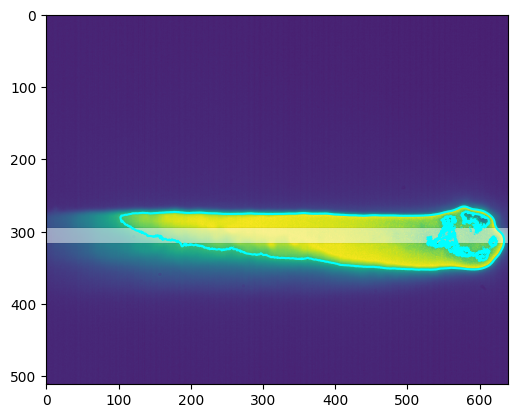

In [7]:
contour_level = 1e4

plt.imshow(np.flipud(array_raw_image))
plt.imshow(pyrometer_wake)
plt.contour(np.flipud(array_raw_image), levels=[contour_level], colors='cyan', linewidths=1.5)
plt.show()

#### Support array

In [8]:
# upper_limit: defined at the beginning of the notebook.
delay = params_clip[int_id_cordon]['delay']
upper_limit = params_clip[int_id_cordon]['upper limit px']

direction = int_id_cordon % 2 == 0

y_matrix_pos = (np.arange(0, 512) - upper_limit)*FAC
x_matrix_pos = (np.arange(639, -1, -1) if direction else np.arange(0, 640))*FAC

if direction:
    x = 640 - int(delay * 16.7 / FAC)
    x_matrix_pos-=delay * 16.7
else:
    x = int(delay * 16.7 / FAC)
    x_matrix_pos-=delay * 16.7

ref_point = (x, int(upper_limit + hauteur/2))

chi, zeta = np.meshgrid(
    np.abs(x_matrix_pos), y_matrix_pos
)

mask_prof = np.zeros_like(zeta, dtype=bool)
mask_prof[:upper_limit,:]=True  # True == unwanted values



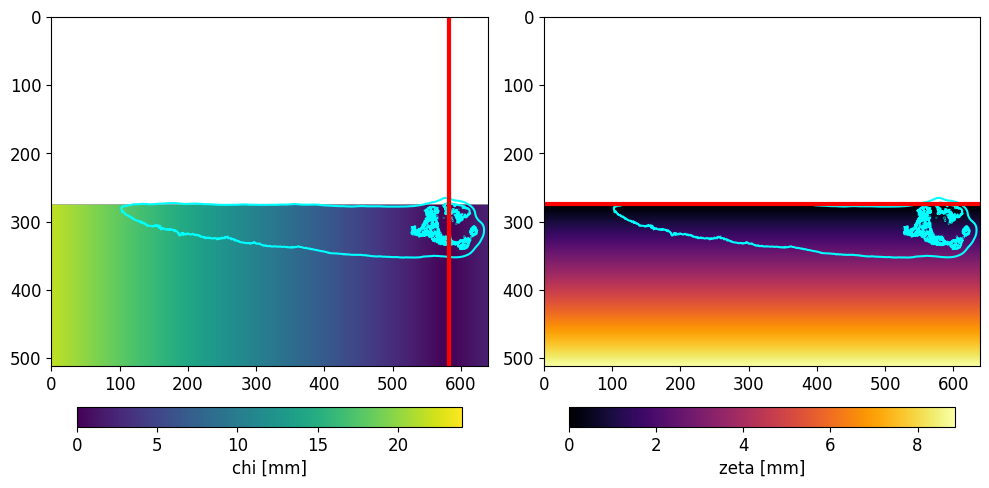

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

contour_level = 1e4
contour_masked = np.ma.masked_array(np.flipud(array_raw_image))
for ax in axes:
    ax.contour(contour_masked, levels=[contour_level], colors='cyan', linewidths=1.5)

im1 = axes[0].imshow(np.ma.masked_array(chi, mask_prof), cmap='viridis', vmin=0, vmax=24)
# axes[0].set_title('time contribution')
if direction == True:
    axes[0].vlines(x=640-int(delay*16.7/FAC), ymin=0, ymax=512, color='r', lw=3)
else:
    axes[0].vlines(x=int(delay*16.7/FAC), ymin=0, ymax=512, color='r', lw=3)

# axes[0].axis('off')  # Désactiver les axes
cbar1 = fig.colorbar(im1, ax=axes[0], orientation='horizontal', fraction=0.046, pad=0.10)
cbar1.set_label('chi [mm]', fontsize=12)
cbar1.ax.tick_params(labelsize=12) 

im2 = axes[1].imshow(np.ma.masked_array(zeta, mask_prof), cmap='inferno')
# axes[1].set_title('depth contribution')
axes[1].hlines(y=upper_limit, xmin=0, xmax=640, color='r', lw=3)
# axes[1].axis('off')  # Désactiver les axes
cbar2 = fig.colorbar(im2, ax=axes[1], orientation='horizontal', fraction=0.046, pad=0.10)
cbar2.set_label('zeta [mm]', fontsize=12)
cbar2.ax.tick_params(labelsize=12) 

for ax in axes.flatten():
    ax.set_xlim(0, 639)
    ax.set_ylim(511, 0)
    ax.tick_params(axis='both', which='major', labelsize=12)

# Afficher la figure
plt.tight_layout()
# plt.savefig("../resultats/time_and_depth_array_contribution.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### Get images

#### Uniform emissivity field (0.73)

In [10]:
# Emissivity field
uniform_emissivity_field_middle = np.ones_like(array_raw_image) * 0.73

# Thermal image from homogenous emissivity field
thermal_image_uniform_emissivity_field_middle = np.flipud(
        dl_to_thermo(
            dl_raw=array_raw_image,
            nuc_table=array_nuc,
            calibration_table=array_calibration,
            emissivity=uniform_emissivity_field_middle
        )
)


#### First order heterogenous emissivity field

In [11]:
# Emissivity field
emissivity_field_first_order = first_order_emissivity_article(
    chi=chi,
    zeta=zeta,
)

# Thermal image from heterogenous emissivity field
thermal_image_first_order_emissivity_field = np.flipud(
        dl_to_thermo(
            dl_raw=array_raw_image,
            nuc_table=array_nuc,
            calibration_table=array_calibration,
            emissivity=np.flipud(emissivity_field_first_order)
        )
)

### Set images

In [12]:
DICT_STUDY_DATA['Uniform (0.73)']['thermal image'] = thermal_image_uniform_emissivity_field_middle
DICT_STUDY_DATA['Uniform (0.73)']['emissivity field'] = uniform_emissivity_field_middle

DICT_STUDY_DATA['First order']['thermal image'] = thermal_image_first_order_emissivity_field
DICT_STUDY_DATA['First order']['emissivity field'] = emissivity_field_first_order

In [13]:
method = 'First order'
label = 'FO'

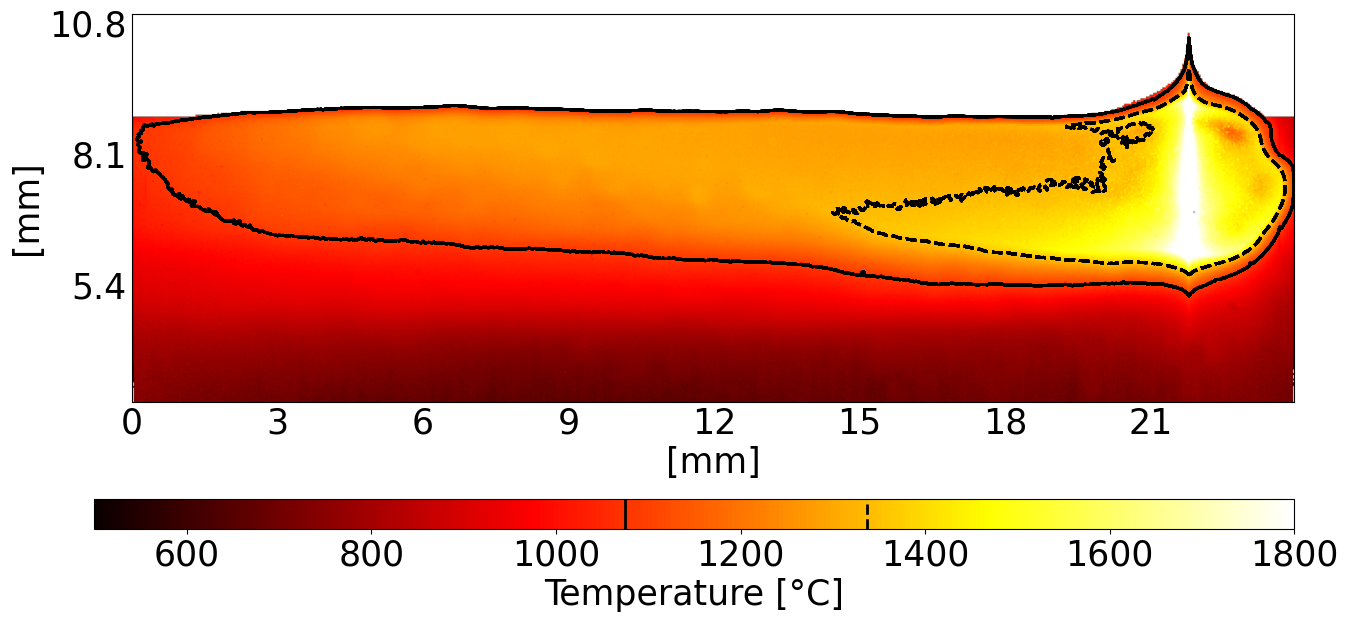

In [14]:
# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)


# Plot setup
fig, ax = plt.subplots(figsize=(15, 6))

thermal_image = np.copy(DICT_STUDY_DATA[method]['thermal image'])
mask_image_to_plot = np.logical_and(
    (
        np.logical_or(
            (thermal_image < 1300), (np.isnan(thermal_image))
        )
    ),
    (zeta < 0),
)

image_to_plot = np.ma.masked_array(thermal_image, mask_image_to_plot)

# Find contours
contours = measure.find_contours(image_to_plot, T_SOLIDUS_GANDIN)
largest_contour = max(contours, key=len)
largest_contour = np.array(largest_contour)
symmetrical_contour = largest_contour.copy()
symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis

contours_liq = measure.find_contours(image_to_plot, T_LIQUIDUS_GANDIN)
IS_LIQUIDUS = False
if len(contours_liq) > 0:
    IS_LIQUIDUS = True
    largest_contour_liq = max(contours_liq, key=len)
    largest_contour_liq = np.array(largest_contour_liq)
    symmetrical_contour_liq = largest_contour_liq.copy()
    symmetrical_contour_liq[:, 0] = LINES_CRED - largest_contour_liq[:, 0]  # Symmetry on Y-axis
    for contour in contours:
        ax.plot(FAC * symmetrical_contour_liq[:, 1], FAC * symmetrical_contour_liq[:, 0], color='k', ls='--', linewidth=2)

# Plot thermal image
im = ax.imshow(image_to_plot - 273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)

# Overlay pyrometer wake
# ax.imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

# Set ticks and labels
ax.set_xticks(xtick_pixels * FAC)
ax.set_yticks(ytick_pixels * FAC)
ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC], fontsize=25)
ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC], fontsize=25)

# Axis labels and limits
ax.set_xlabel('[mm]', fontsize=25)
ax.set_xlim(0, (COLUMNS_CRED - 1) * FAC)
ax.set_ylim(0, (LINES_CRED - 1) * FAC)

# Crop limits
crop_min = params_clip[int_id_cordon]['crop low']
crop_max = params_clip[int_id_cordon]['crop high']
ax.set_ylim(crop_min, crop_max)

# Plot contours
for contour in contours:
    ax.plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='k', ls='-', linewidth=2)

ax.tick_params(axis='both', which='both', length=0)

# Colorbar setup
ax.set_ylabel('[mm]', fontsize=25)
cbar_ax = fig.add_axes([0.1, -0.04, 0.8, 0.05])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature [°C]', fontsize=25)
cbar.ax.tick_params(labelsize=25)
cbar.ax.axvline(T_SOLIDUS_GANDIN-273.15, color='k', ls='-', linewidth=2)
cbar.ax.axvline(T_LIQUIDUS_GANDIN-273.15, color='k', ls='--', linewidth=2)

# Display plot
#fig.tight_layout()
# fig.savefig(os.path.join(saving_path ,f"article_Thermal_Map_{label}_{int_id_cordon}_V3.pdf"), format='pdf', bbox_inches='tight')
plt.show()

0.7796658979986494


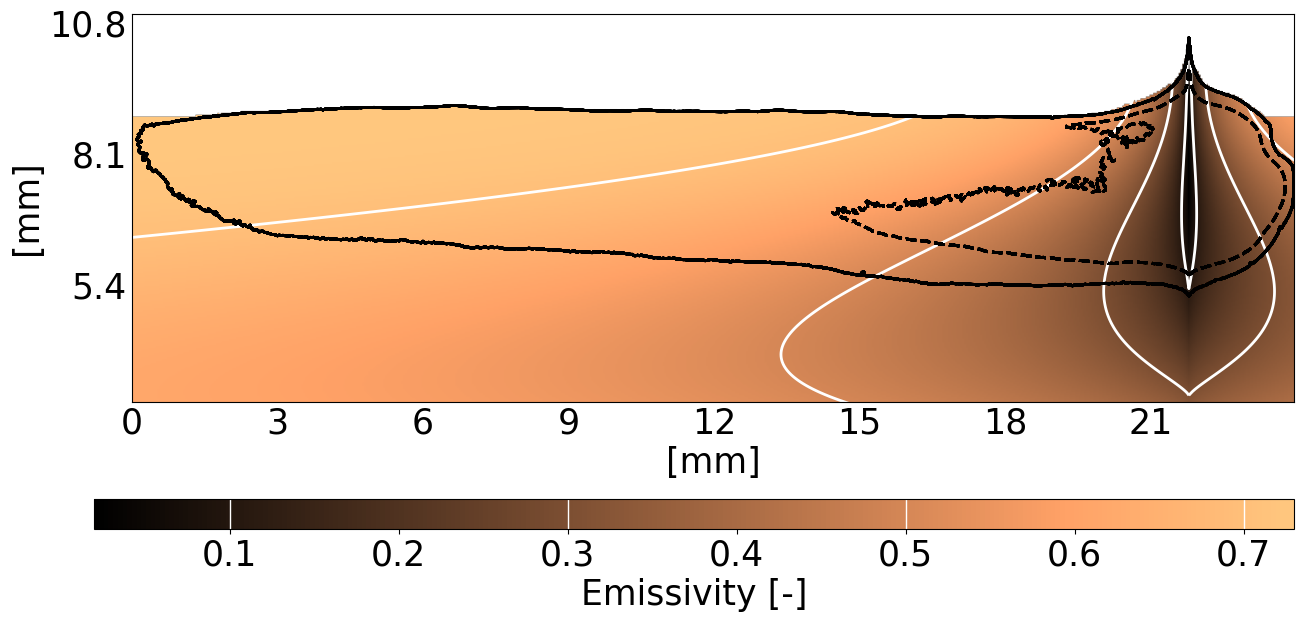

In [15]:
fontsize = 25

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
levels = [0.1, 0.3, 0.5, 0.7]
# Plot setup
fig, ax = plt.subplots(figsize=(15, 6))

emissivity_field = np.copy(DICT_STUDY_DATA[method]['emissivity field'])


emissivity_field_masked = np.copy(emissivity_field)
emissivity_field_masked[mask_image_to_plot] = np.nan
print(np.nanmax(emissivity_field_masked))
im = ax.imshow(emissivity_field_masked, cmap='copper', extent=extent, vmin=0.02, vmax=0.73)
iso_emi = ax.contour(np.flipud(emissivity_field), levels=levels, colors='white', linewidths=2, extent=extent)
# ax.clabel(iso_emi, inline=False, fontsize=10, fmt='%.4f')

# Overlay pyrometer wake
# ax.imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

# Set ticks and labels
ax.set_xticks(xtick_pixels * FAC)
ax.set_yticks(ytick_pixels * FAC)
ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC], fontsize=fontsize)
ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC], fontsize=fontsize)

# Axis labels and limits
ax.set_xlabel('[mm]', fontsize=fontsize)
ax.set_xlim(0, (COLUMNS_CRED - 1) * FAC)
ax.set_ylim(0, (LINES_CRED - 1) * FAC)

# Crop limits
crop_min = params_clip[int_id_cordon]['crop low']
crop_max = params_clip[int_id_cordon]['crop high']
ax.set_ylim(crop_min, crop_max)

ax.tick_params(axis='both', which='both', length=0)

for contour in contours:
    ax.plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='k', linewidth=2, ls="-")
    if IS_LIQUIDUS:
        ax.plot(FAC * symmetrical_contour_liq[:, 1], FAC * symmetrical_contour_liq[:, 0], color='k', linewidth=2, ls='--')

# Colorbar setup
ax.set_ylabel('[mm]', fontsize=fontsize)
cbar_ax = fig.add_axes([0.1, -0.04, 0.8, 0.05])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Emissivity [-]', fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize)
for level in levels:
    cbar.ax.axvline(level, color='white', linewidth=1)

# Display plot
# fig.savefig(os.path.join(saving_path ,f"article_Emissivity_Field_{label}_{int_id_cordon}_V3.pdf"), format='pdf', bbox_inches='tight')
plt.show()

### Melt Poll Dynamics Calculation

In [16]:
crop_data=(200,0,250,639)

working_image = DICT_STUDY_DATA[method]['thermal image']

# Compute thermal gradient resolving an illness problem using Fourier transformation
GradThermal = RegularizedThermalGradient(
    raw_image=working_image,
    crop_data=crop_data,
    harmonics_X=30,
    harmonics_Y=15,
    scale=FAC,
    manual_alpha=0.09,
    optimized=True
)

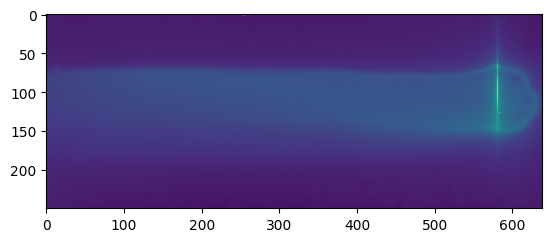

In [35]:
crop_data=(200,0,250,639)

working_image = DICT_STUDY_DATA[method]['thermal image']

plt.imshow(working_image[crop_data[0]:crop_data[0]+crop_data[2], crop_data[1]:crop_data[1]+crop_data[3]])
plt.show()

# plt.imshow(working_image)
# plt.show()

Processing alpha: 100%|██████████| 8/8 [00:00<00:00, 7572.65it/s]


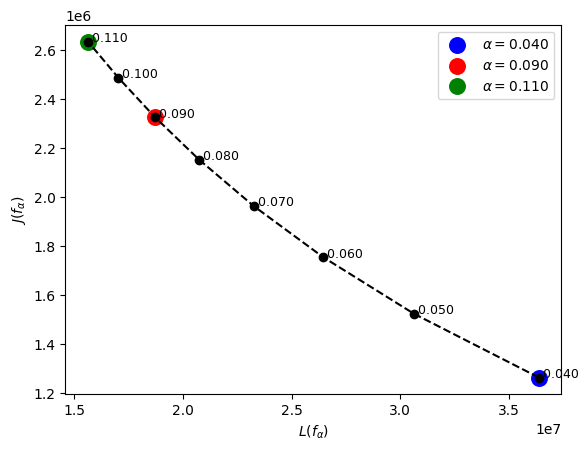

In [ ]:
# GradThermal.show_L_curve(np.arange(0.04, 0.12, 0.01))

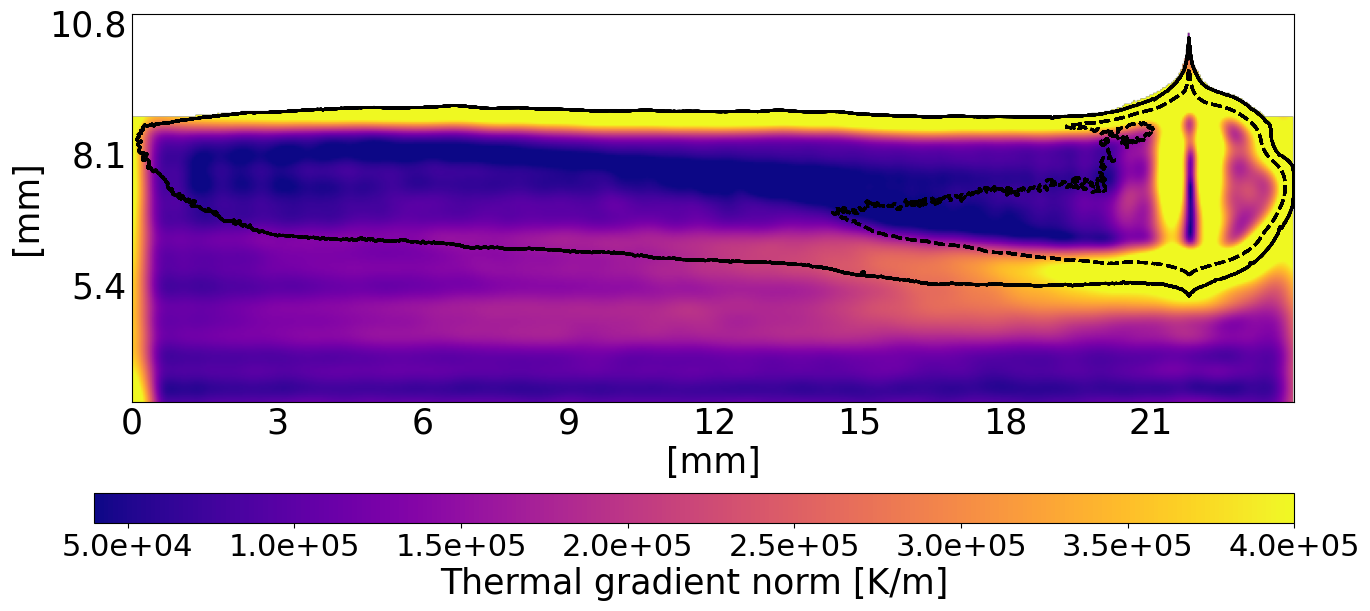

In [ ]:
from matplotlib.ticker import StrMethodFormatter

fontsize=25

norm_grad = np.copy(GradThermal.thermal_gradient_norm)

levels = [1e5, 2e5, 3e5, 4e5, 5e5, 6e5]

x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

fig, ax = plt.subplots(figsize=(15, 6))

norm_grad_masked = np.copy(norm_grad)
norm_grad_masked[mask_image_to_plot]= np.nan

im = ax.imshow(norm_grad_masked, cmap='plasma', extent=extent, vmin=4e4, vmax=4e5)
# iso_emi = ax.contour(np.flipud(norm_grad), colors='white', levels=levels,  linewidths=2, extent=extent)
# ax.clabel(iso_emi, inline=False, fontsize=10, fmt='%.4f')

# Set ticks and labels
ax.set_xticks(xtick_pixels * FAC)
ax.set_yticks(ytick_pixels * FAC)
ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC], fontsize=fontsize)
ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC], fontsize=fontsize)

# Axis labels and limits
ax.set_xlabel('[mm]', fontsize=fontsize)
ax.set_xlim(0, (COLUMNS_CRED - 1) * FAC)
ax.set_ylim(0, (LINES_CRED - 1) * FAC)

# Crop limits
crop_min = params_clip[int_id_cordon]['crop low']
crop_max = params_clip[int_id_cordon]['crop high']
ax.set_ylim(crop_min, crop_max)

ax.tick_params(axis='both', which='both', length=0)

for contour in contours:
    ax.plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='k', linewidth=2, ls="-")
    if IS_LIQUIDUS:
        ax.plot(FAC * symmetrical_contour_liq[:, 1], FAC * symmetrical_contour_liq[:, 0], color='k', linewidth=2, ls='--')

ax.set_ylabel('[mm]', fontsize=fontsize)
cbar_ax = fig.add_axes([0.1, -0.03, 0.8, 0.05])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Thermal gradient norm [K/m]', fontsize=fontsize)
cbar.ax.tick_params(labelsize=22)

# Configuration des ticks
cbar.formatter = StrMethodFormatter("{x:.1e}")  # Format "1e5", "2e5", etc.
cbar.update_ticks()

cbar.update_ticks()
# for level in levels:
#     cbar.ax.axvline(level, color='white', linewidth=1)

# fig.savefig(os.path.join(saving_path ,f"article_gradient_norm_{label}_{int_id_cordon}_V3.pdf"), format='pdf', bbox_inches='tight')
plt.show()

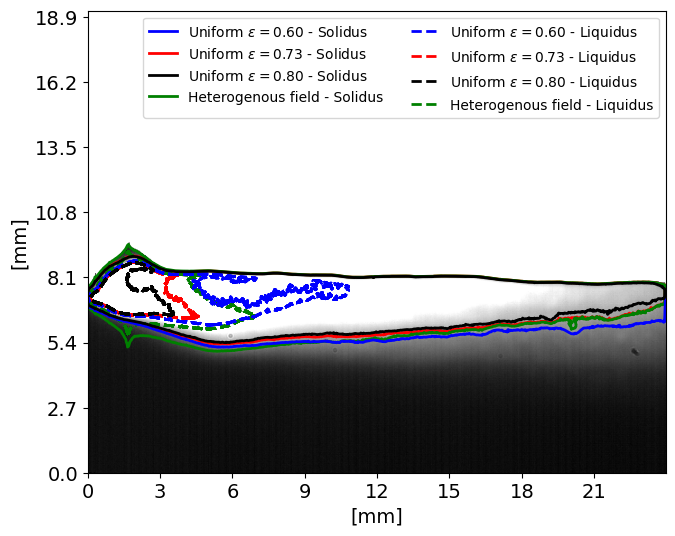

In [20]:
from matplotlib.lines import Line2D

x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

fig, ax = plt.subplots(figsize=(15, 6))

norm_grad_masked = np.copy(np.flipud(array_raw_image))
norm_grad_masked[mask_image_to_plot]= np.nan

ax.imshow(norm_grad_masked, cmap='gray', extent=extent, vmin=1e3, vmax=9e3)
# Set ticks and labels
ax.set_xticks(xtick_pixels * FAC)
ax.set_yticks(ytick_pixels * FAC)
ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC], fontsize=14)
ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC], fontsize=14)

# Axis labels and limits
ax.set_ylabel('[mm]', fontsize=14)
ax.set_xlabel('[mm]', fontsize=14)
ax.set_xlim(0, (COLUMNS_CRED - 1) * FAC)
ax.set_ylim(0, (LINES_CRED - 1) * FAC)


for color, key in zip(
    ['r', 'g', 'b', 'k'], 
    ['Uniform (0.73)', 'First order', 'Uniform (0.6)', 'Uniform (0.8)']
):
    working_image = DICT_STUDY_DATA[key]['thermal image']
    image_to_plot = np.ma.masked_array(working_image, mask_image_to_plot)

    # Find contours
    contours = measure.find_contours(image_to_plot, T_SOLIDUS_GANDIN)
    largest_contour = max(contours, key=len)
    largest_contour = np.array(largest_contour)
    symmetrical_contour = largest_contour.copy()
    symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis
    ax.plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color=color, ls='-', linewidth=2)

    contours_liq = measure.find_contours(image_to_plot, T_LIQUIDUS_GANDIN)
    IS_LIQUIDUS = False
    if len(contours_liq) > 0:
        IS_LIQUIDUS = True
        largest_contour_liq = max(contours_liq, key=len)
        largest_contour_liq = np.array(largest_contour_liq)
        symmetrical_contour_liq = largest_contour_liq.copy()
        symmetrical_contour_liq[:, 0] = LINES_CRED - largest_contour_liq[:, 0]  # Symmetry on Y-axis
        for contour in contours:
            ax.plot(FAC * symmetrical_contour_liq[:, 1], FAC * symmetrical_contour_liq[:, 0], color=color, ls='--', linewidth=2)


legend_elements = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-', label=r'Uniform $\varepsilon = 0.60$ - Solidus'),
    Line2D([0], [0], color='red', lw=2, linestyle='-', label=r'Uniform $\varepsilon = 0.73$ - Solidus'),
    Line2D([0], [0], color='black', lw=2, linestyle='-', label=r'Uniform $\varepsilon = 0.80$ - Solidus'),
    Line2D([0], [0], color='green', lw=2, linestyle='-', label=r'Heterogenous field - Solidus'),
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label=r'Uniform $\varepsilon = 0.60$ - Liquidus'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label=r'Uniform $\varepsilon = 0.73$ - Liquidus'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label=r'Uniform $\varepsilon = 0.80$ - Liquidus'),
    Line2D([0], [0], color='green', lw=2, linestyle='--', label=r'Heterogenous field - Liquidus'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, ncols=2)
# fig.savefig(os.path.join(saving_path ,f"Tsol_Tliq_4methods.pdf"), format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
crop_data=(200,0,250,639)

for key in list_method:

    with open(
        os.path.join(saving_path ,f"MP_size_{int_id_cordon}_{key}.txt"), "w"
        ) as MP_dimensions:
    
        working_image = DICT_STUDY_DATA[key]['thermal image']

        # Compute thermal gradient resolving an illness problem using Fourier transformation
        GradThermal = RegularizedThermalGradient(
            raw_image=working_image,
            crop_data=crop_data,
            harmonics_X=30,
            harmonics_Y=15,
            scale=FAC,
            manual_alpha=0.1,
            optimized=True
        )
            
        # Get the Fourier images rescaled into the field of view of the camera
        Fourier_image = GradThermal.get_Fourier_formulation_vectorized()
        resized_Fourier_image = GradThermal.resize_to_original(
            image_to_resize=np.ma.masked_array(Fourier_image, GradThermal.mask_filled)
        )

        # Quantify isotherm shape using a quarter of ellipsoid and get the thermal information on it
        isotherm_length, isotherm_depth, isotherm_coordinates, gradient_on_isotherm, \
            thermal_orientation_on_isotherm, solidification_rate_on_isotherm, hunt_criteria_coordinates = hunt_data_on_isotherm(
                working_image=working_image,
                direction=direction,
                T_target=T_SOLIDUS_GANDIN,
                reference_point=ref_point,
                norm_thermal_gradient=GradThermal.thermal_gradient_norm,
                orientation_thermal_gradient=GradThermal.thermal_gradient_orientation,
                save_path=False
            )
        
        display_G_and_R_on_images_old(
            image_to_plot=working_image,
            T_target=T_SOLIDUS_GANDIN,
            hunt_coo=hunt_criteria_coordinates,
            filtered_gradient=gradient_on_isotherm,
            filtered_orientation=thermal_orientation_on_isotherm,
            crop_y_axis=(crop_data[0] + crop_data[2], crop_data[0]),
            saving_path=os.path.join(saving_path, f'G_R_on_image_{int_id_cordon}_{key}.png')
        )


        # Classify the growth mode according to the Hunt criterion for IN718
        list_growth_mode = classify_growth_mode(
            thermal_gradient_data=gradient_on_isotherm,
            solidification_rate_data=np.abs(solidification_rate_on_isotherm),
            power_fit_params=CET_IN718_fitting_parameters
        )

        # Set information
        DICT_STUDY_DATA[key]['Fourier thermal image'] = resized_Fourier_image
        DICT_STUDY_DATA[key]['shape quantification'] = (isotherm_length, isotherm_depth)
        DICT_STUDY_DATA[key]['coordinates isotherm'] = isotherm_coordinates
        DICT_STUDY_DATA[key]['thermal gradient on isotherm'] = gradient_on_isotherm
        DICT_STUDY_DATA[key]['thermal gradient orientation on isotherm'] = GradThermal.thermal_gradient_orientation[hunt_criteria_coordinates]
        DICT_STUDY_DATA[key]['solidification rate on isotherm'] = np.abs(solidification_rate_on_isotherm)
        DICT_STUDY_DATA[key]['hunt criteria coordinates'] = hunt_criteria_coordinates
        DICT_STUDY_DATA[key]['classify growth mode'] = list_growth_mode

        MP_dimensions.write(f"{key} {isotherm_length} {isotherm_depth}\n")

#### Hunt graphic

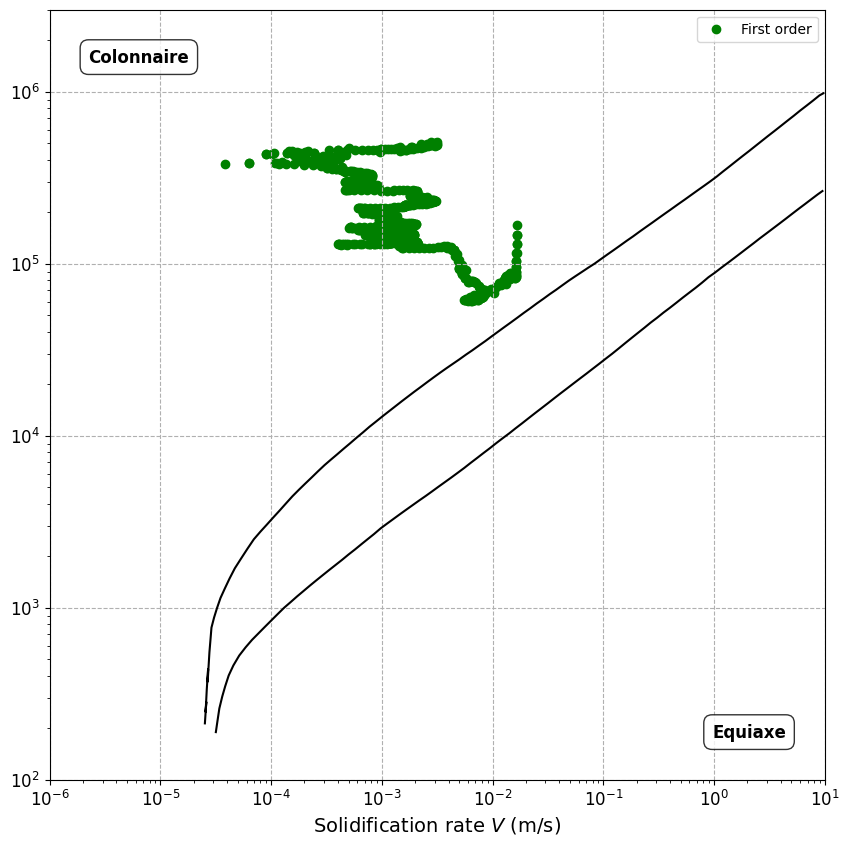

In [44]:

file_path = os.path.join(BASE_DIR, "TherMIFASOL/resources/CET_INCONEL")

V_col, G_col = np.loadtxt(os.path.join(file_path, "columnar_CET.txt")).T
V_equ, G_equ = np.loadtxt(os.path.join(file_path, "equiaxed_CET.txt")).T

fig, ax = plt.subplots(figsize=(10, 10))

ax.loglog(V_col, G_col, c='k')
ax.loglog(V_equ, G_equ, c='k')
# Ajouter du texte en haut à gauche et en bas à droite
ax.text(
    0.05, 0.95, 'Colonnaire', transform=ax.transAxes, fontsize=12, fontweight='bold',
    verticalalignment='top', horizontalalignment='left', bbox=dict(facecolor='white', boxstyle='round,pad=0.5', alpha=0.8))
ax.text(
    0.95, 0.05, f'Equiaxe', transform=ax.transAxes, fontsize=12, fontweight='bold',
    verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', boxstyle='round,pad=0.5', alpha=0.8))

for color, method in zip(['g'], ['First order']):

    # classification = DICT_STUDY_DATA[method]['classify growth mode']
    G_data = DICT_STUDY_DATA[method]['thermal gradient on isotherm' ]
    R_data = np.abs(DICT_STUDY_DATA[method]['solidification rate on isotherm'])

    ax.scatter(R_data, G_data, color=color, label=method)
    
# ax.set_title(method)
ax.set_xlim(1e-6, 1e1)
ax.set_ylim(1e2, 3e6)
ax.set_xlabel('Solidification rate $V$ (m/s)', fontsize=14)
if method == 'Uniform':
    ax.set_ylabel('Thermal gradient $G$ (K/m)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)

# Display the grid
ax.grid(True, which="major", ls="--")
ax.legend()
# fig.savefig(os.path.join(saving_path ,f"Hunt_id{int_id_cordon}.pdf"), format='pdf', bbox_inches='tight')
plt.show()

# Loop on full layers

In [4]:
list_of_layers = np.arange(6, 17, dtype=int)
list_of_methods = ['FO', 'U73']

ALL_LAYERS_STUDY = {
    layer: {
        method: {} for method in list_of_methods
    } for layer in list_of_layers
}


In [ ]:
for layer in list_of_layers:

    # if layer > 10:
    #     crop_data=(200,0,250,639)
    # else:
    #     crop_data=(262,0,250,639)

    crop_data=(200,0,312,639)

    for method in list_of_methods:

        print(layer, method)

        int_img_selected = params_clip[layer]['snapshot']

        # Take the raw image
        array_raw_image = load_cred_array(
            path_image=os.path.join(data_path, f"CRED/data/layer_{layer}/im_{int_img_selected}.npy")
        )
        
        # Create mask
        ref_point, chi, zeta, direction, mask_prof = create_position_mesh(
            params_clip=params_clip,
            int_id_cordon=layer,
            FAC=FAC
            )
        
        # Compute thermal maps
        if method == 'FO':
            emissivity_field = first_order_emissivity_article(
                chi=chi,
                zeta=zeta,
            )
            thermal_image = np.flipud(
                    dl_to_thermo(
                        dl_raw=array_raw_image,
                        nuc_table=array_nuc,
                        calibration_table=array_calibration,
                        emissivity=np.flipud(emissivity_field)
                    )
            )
            
        elif method == 'U73':
            emissivity_field = np.ones_like(array_raw_image) * 0.73

            thermal_image = np.flipud(
                    dl_to_thermo(
                        dl_raw=array_raw_image,
                        nuc_table=array_nuc,
                        calibration_table=array_calibration,
                        emissivity=emissivity_field
                    )
            )


        # Compute thermal gradient resolving an illness problem using Fourier transformation
        GradThermal = RegularizedThermalGradient(
            raw_image=thermal_image,
            crop_data=crop_data,
            harmonics_X=30,
            harmonics_Y=15,
            scale=FAC,
            manual_alpha=0.09,
            optimized=True
        )

        # Get the Fourier images rescaled into the field of view of the camera
        Fourier_image = GradThermal.get_Fourier_formulation_vectorized()
        resized_Fourier_image = GradThermal.resize_to_original(
            image_to_resize=np.ma.masked_array(Fourier_image, GradThermal.mask_filled)
        )

        # Quantify isotherm shape using a quarter of ellipsoid and get the thermal information on it
        isotherm_length, isotherm_depth, isotherm_coordinates, gradient_on_isotherm, \
            thermal_orientation_on_isotherm, solidification_rate_on_isotherm, hunt_criteria_coordinates = hunt_data_on_isotherm(
                working_image=thermal_image,
                direction=direction,
                T_target=T_SOLIDUS_GANDIN,
                reference_point=ref_point,
                norm_thermal_gradient=GradThermal.thermal_gradient_norm,
                orientation_thermal_gradient=GradThermal.thermal_gradient_orientation,
                save_path=False
            )
        
        classification = classify_growth_mode(gradient_on_isotherm, np.abs(solidification_rate_on_isotherm), CET_IN718_fitting_parameters)
        epitaxie = True if np.all(classification == 0) else False  

        display_G_and_R_on_images(
            image_to_plot=thermal_image, 
            T_target=T_SOLIDUS_GANDIN, 
            hunt_coo=hunt_criteria_coordinates, 
            filtered_gradient=gradient_on_isotherm,
            filtered_orientation=thermal_orientation_on_isotherm, 
            crop_y_axis=(crop_data[0] + crop_data[2], crop_data[0]), 
            saving_path=os.path.join(saving_path, f'{layer}_{method}'),
            ref_point=ref_point,
            solidification_rate_on_isotherm=np.abs(solidification_rate_on_isotherm),
            semi_axis=(isotherm_length, isotherm_depth),
            int_id_cordon=layer,
            path_to_CET=CET_path
            )
    
        ALL_LAYERS_STUDY[layer][method]['shape quantification'] = (isotherm_length, isotherm_depth)
        ALL_LAYERS_STUDY[layer][method]['epitaxie'] = epitaxie


## Melt Pool Size

In [6]:
methods = ['U73', 'FO']
colors = {'U73': 'darkorange', 'FO': 'darkviolet'}

L_U73, D_U73, E_U73 = [], [], []
L_FO, D_FO, E_FO = [], [], []

for id_cordon in list_of_layers:
    length, depth = ALL_LAYERS_STUDY[id_cordon]['U73']['shape quantification']
    epitaxie = ALL_LAYERS_STUDY[layer]['U73']['epitaxie']
    L_U73.append(length*FAC)
    D_U73.append(depth*FAC)
    E_U73.append(epitaxie)

    length, depth = ALL_LAYERS_STUDY[id_cordon]['FO']['shape quantification']
    epitaxie = ALL_LAYERS_STUDY[layer]['FO']['epitaxie']
    L_FO.append(length*FAC)
    D_FO.append(depth*FAC)
    E_FO.append(epitaxie)

L_U73 = np.asarray(L_U73)
D_U73 = np.asarray(D_U73)
L_FO = np.asarray(L_FO)
D_FO = np.asarray(D_FO)

print(L_U73)
print(D_U73)

[24.38575561 36.67499144 24.96056182 28.28482802 26.09107132 22.44167631
 24.46633931 24.19569812 21.54273317 22.22759899 23.1955347 ]
[3.06542569 2.45017413 2.91315191 1.92478341 2.80359568 1.84527617
 2.73971807 1.97644971 2.70856364 1.9876005  2.76411964]


/home/dolle/Documents/3_These doctorat/6_python/Thermique MIFASOL/results/article/test


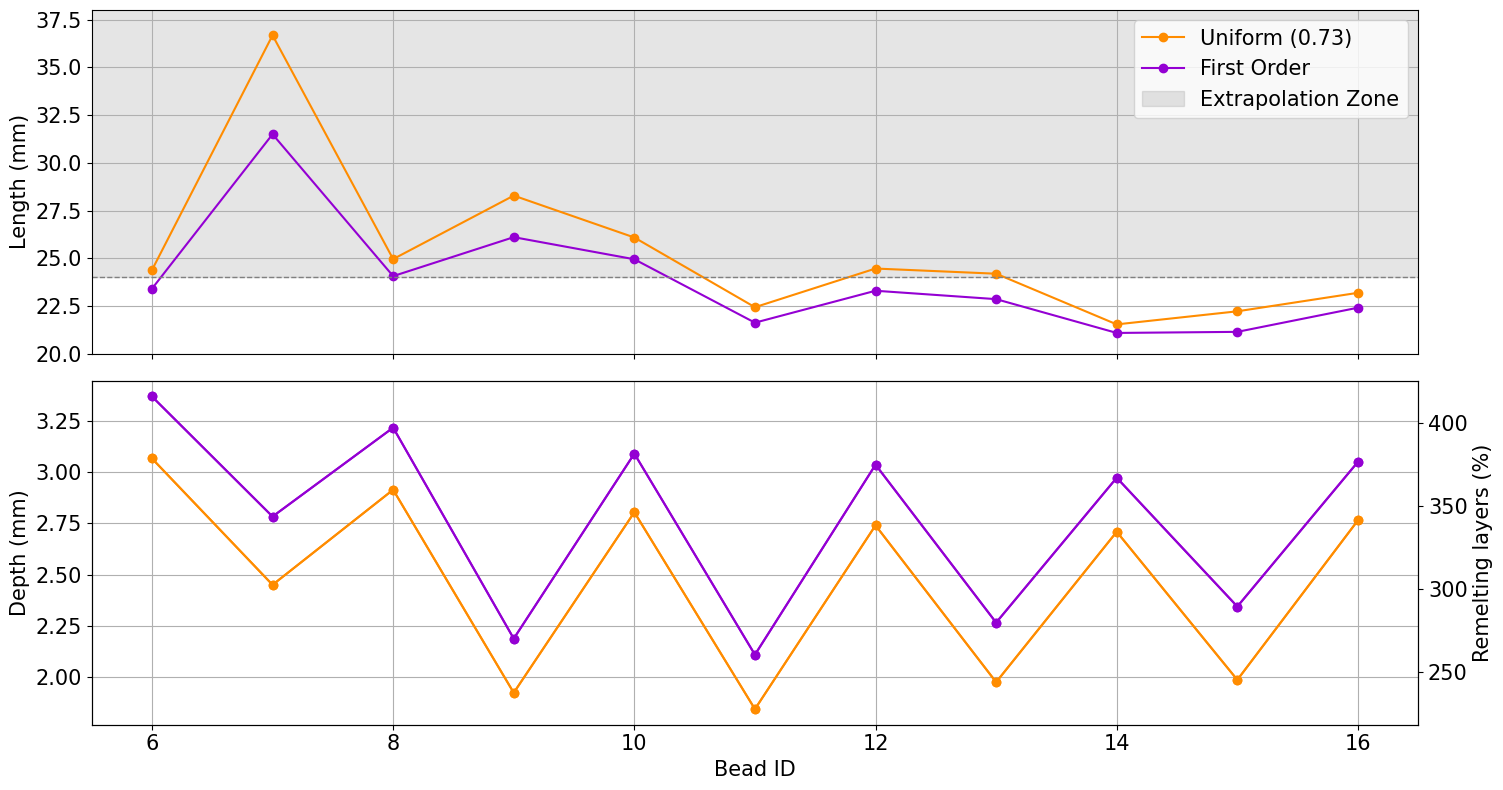

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Variables pour ajuster le fontsize
fontsize_ticks = 15  # Taille de police pour les ticks
fontsize_labels = 15  # Taille de police pour les labels des axes
fontsize_legends = 15  # Taille de police pour les légendes

# Longueurs
ax1.plot(list_of_layers, L_U73, 'o-', label='Uniform (0.73)', color='darkorange')
ax1.plot(list_of_layers, L_FO, 'o-', label='First Order', color='darkviolet')
extrapolation_limit = 24  # Exemple : limite à partir de laquelle c'est une extrapolation
ax1.axhline(y=extrapolation_limit, color='gray', linestyle='--', linewidth=1)
ax1.fill_between([5, 17], extrapolation_limit, 39,
                  color='gray', alpha=0.2, label='Extrapolation Zone')

ax1.set_ylabel("Length (mm)", fontsize=fontsize_labels)
ax1.tick_params(axis='both', labelsize=fontsize_ticks)
ax1.legend(fontsize=fontsize_legends)
ax1.set_ylim(20, 38)
ax1.set_xlim(5.5, 16.5)
ax1.grid(True)

# Profondeurs
ax2.plot(list_of_layers, D_U73, 'o-', label='Uniform (0.73)', color='darkorange')
ax2.plot(list_of_layers, D_FO, 'o-', label='First Order', color='darkviolet')
ax2.set_ylabel("Depth (mm)", fontsize=fontsize_labels)
ax2.set_xlabel("Bead ID", fontsize=fontsize_labels)
ax2.tick_params(axis='both', labelsize=fontsize_ticks)
# ax2.legend(fontsize=fontsize_legends)

ax2_twin = ax2.twinx()
percentage_U73 = (D_U73 / 0.81) * 100
percentage_FO = (D_FO / 0.81) * 100
ax2_twin.plot(list_of_layers, percentage_U73, 'o-', color='darkorange')
ax2_twin.plot(list_of_layers, percentage_FO, 'o-',  color='darkviolet')
ax2_twin.set_ylabel("Remelting layers (%)", fontsize=fontsize_labels)
ax2_twin.tick_params(axis='both', labelsize=fontsize_ticks)

ax2.set_xlim(5.5, 16.5)
ax2.grid(True)

plt.tight_layout()

print(saving_path)
fig.savefig(os.path.join(saving_path ,f"MP_geometry_V2.pdf"), format='pdf', bbox_inches='tight')
plt.show()